# Checking The Overfitting

Aşırı öğrenme önlemleri alarak breast canser veri seti için yeni bir model geliştiriniz.

Dikkat edilmesi gerekenler:

- sklearn içerisinde yer alan breast cancer veri setini kullanınız. (from sklearn.datasets import load_breast_cancer)

- Veri ön işleme adımında makine öğrenmesindeki bilgilerinizi kullanabilirsiniz.

- Tensorflow dataset için tanımladığımız fonksiyonu kullanınız ve batch_size'ı 32 yapınız.

- 1 gizli katmanlı basit bir model oluşturunuz. Nöron sayısını istediğiniz gibi tercih edebilirsiniz.

- Aşırı öğrenme problemine karşı uygun katman yapılarını ve callback'i kullanınız.

- Model compile bölümünde SGD'yi direkt kullanınız yani compile içinde optimizer="SGD" şeklinde kullanınız.

- Overfitting'den şüphelendiğimiz için early stopping'de küçük bir değer giriniz.

- En iyi epoch sonucunu yorumlayınız.

- Loss eğrisini yorumlayınız.

- İfade edilmeyen konularda tercih size bırakılmıştır.

- Notebook'ta genel yapılar ve gidiş yolu için yönlendirmeler bırakılmıştır.


In [ ]:
import keras
import tensorflow as tf
print("Keras Current Version:", keras.__version__, "Tensorflow Current Version:", tf.__version__)

Keras Current Version: 3.8.0 Tensorflow Current Version: 2.18.0


In [ ]:
# !pip uninstall tf-keras

In [ ]:
# !pip install tensorflow==2.16.1

# Imports and Settings

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

random.seed(46)
np.random.seed(46)
tf.random.set_seed(46)


# Functions

In [ ]:
def plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric}")
    plt.title(f'Training and Validation {train_metric} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'train_metric')
    plt.legend()
    plt.show()




def prepare_datasets(X_train, X_val, y_train, y_val, batch_size=None):

    if batch_size is None:
        batch_size = len(X_train)

    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_dataset = val_dataset.batch(batch_size)

    return train_dataset, val_dataset


# Data Preprocess, Train Validation and Tensorflow Dataset

# Task 1: Veri setini yükleyiniz ve X ve y'yi alınız.

In [ ]:
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
import pandas as pd
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
X=data.data
y=data.target

In [ ]:
#Check features and target
print("Features:", X.shape)
print("Target:", y.shape)

Features: (569, 30)
Target: (569,)


# Task 2: Train Validasyon seti ayrımını yapınız

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Task 3: X_train ve X_val setlerini standart scaler'dan geçiriniz

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Task 4: Tensorflow Dataset oluşturunuz

In [ ]:
train_ds, val_ds = prepare_datasets(X_train, X_val, y_train, y_val, batch_size=32)

# Model

# Task 5: Model yapısını aşırı öğrenme için uygun katmanları da kullanarak oluşturunuz

In [ ]:
model = Sequential([
    Input(shape=(train_ds.element_spec[0].shape[1],)),

    Dense(50, activation='relu', kernel_regularizer=l2(0.02)), #l2 düzenlileştirme parametresi kullanıyoruz.

    BatchNormalization(), # daha stabil bir öğrenme için aktivasyonları standartlaştırıyoruz.

    Dropout(0.5), # dropout katmanı ekliyoruz.

    Dense(1, activation='sigmoid')
])


# Task 6: Modeli SGD ile, binary_crossentropy ve accuracy, AUC değerleri ile compile ediniz.

In [ ]:
auc_metric = tf.keras.metrics.AUC()

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001,momentum=0.9), #SGD optimizer
    loss='binary_crossentropy', #binary_crossentropy
    metrics=['accuracy',auc_metric] #Accuracy ve Auc metrikleri
)

# Task 7: Early stopping callback'i tanımlayınız.

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, # risk almamak adına patience'ı küçük tutuyoruz.
    verbose=1,
    restore_best_weights=True)

# Task 8: Modeli train ediniz

In [ ]:
history = model.fit(train_ds,
            epochs=1000,
            validation_data=val_ds,
            verbose=1,
            callbacks=[early_stopping])

Epoch 1/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6018 - auc_2: 0.6161 - loss: 1.5890 - val_accuracy: 0.6491 - val_auc_2: 0.8493 - val_loss: 1.3795
Epoch 2/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6315 - auc_2: 0.7095 - loss: 1.4738 - val_accuracy: 0.6842 - val_auc_2: 0.8711 - val_loss: 1.3407
Epoch 3/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6383 - auc_2: 0.7078 - loss: 1.4728 - val_accuracy: 0.7544 - val_auc_2: 0.8911 - val_loss: 1.3025
Epoch 4/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6440 - auc_2: 0.7062 - loss: 1.4508 - val_accuracy: 0.8246 - val_auc_2: 0.9119 - val_loss: 1.2660
Epoch 5/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6557 - auc_2: 0.7436 - loss: 1.3998 - val_accuracy: 0.8158 - val_auc_2: 0.9250 - val_loss: 1.2339
Epoch 6/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7317 - auc_2: 0.7893 - loss: 1.3238 - val_accuracy: 0.8246 - val_auc_2: 0.9347 - val_loss: 1.2046
Epoch 7/1000
15

# Task 9: En iyi epoch değerlerini getiriniz ve yorumlayınız.

In [ ]:
def get_best_epoch_details(history):
    val_losses = history.history['val_loss']
    min_val_loss_index = val_losses.index(min(val_losses))
    best_epoch = min_val_loss_index + 1

    epoch_details = {}
    for key in history.history.keys():
        epoch_details[key] = history.history[key][min_val_loss_index]

    epoch_details['best_epoch'] = best_epoch
    return epoch_details

In [ ]:

best_epoch_details = get_best_epoch_details(history)
print(f"Best epoch details: {best_epoch_details}")

Best epoch details: {'accuracy': 0.9538461565971375, 'auc_2': 0.9876484870910645, 'loss': 0.3489735424518585, 'val_accuracy': 0.9649122953414917, 'val_auc_2': 0.9973796606063843, 'val_loss': 0.2947962284088135, 'best_epoch': 1000}


# Task 10: Train history'sini görselleştiriniz ve yorumlayınız

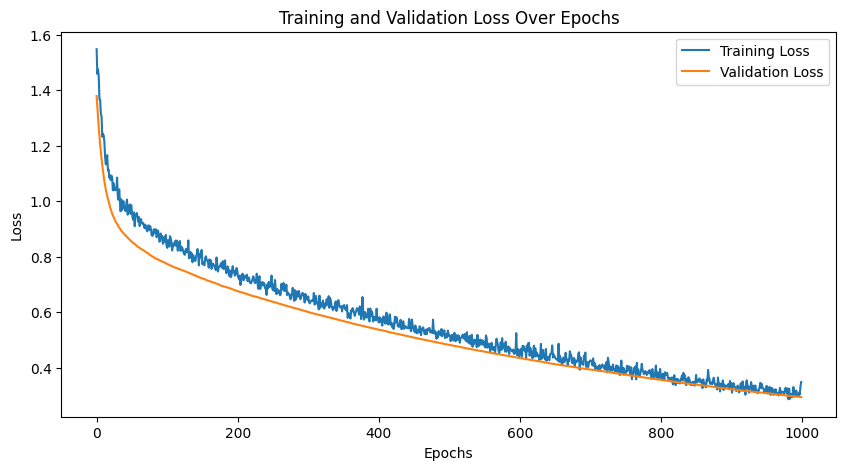

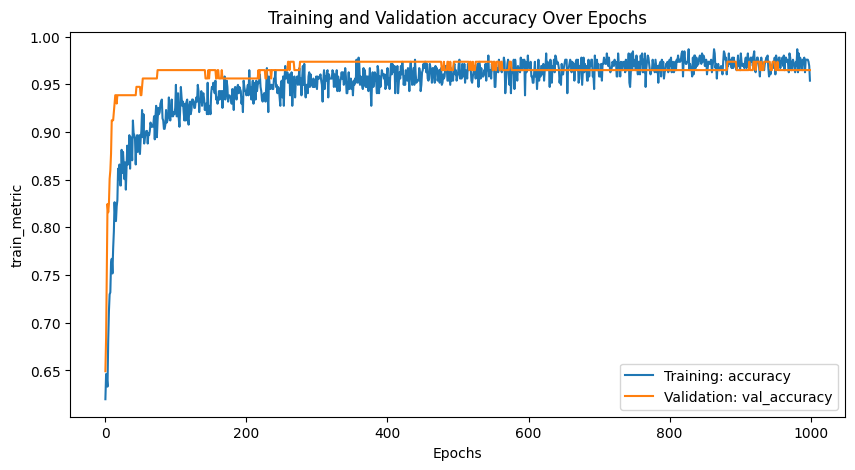

In [ ]:
plot_training_history(history)

'accuracy': 0.9648351669311523, 'auc_1': 0.9939172267913818, 'loss': 0.13866972923278809, 'val_accuracy': 0.9736841917037964, 'val_auc_1': 0.9980347156524658, 'val_loss': 0.10949694365262985, 'best_epoch': 61}


olarak elde etdik. Ve trainLoss un val_loss dan daha çok olduğunu aynı zamanda val_accuracy-nin train_accuracy-den daha çok olduğunu göre biliriz.bu overfitting problemi herhalde modelin çok iyi öğrenmesinden dolayı ola bilir.

# Task 11: Modelin aşırı öğrenme durumu ile ilgili ne düşünüyorsunuz?

Modelin aşırı öğrenme sebebi bu dataset için fazla çaba harcamamız ola bilir. Yani diabets datasl zorlu bir dataset olmadığından küçük işlemler belkide yeterli ola bilir.